In [1]:
# %% 
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, solve
import scipy.signal as sig


In [2]:

def autocorr_1d(x):
    r_full = np.correlate(x, x, mode="full")
    mid = len(r_full) // 2
    return r_full, mid

def supef_decon(x, minlag_samp, maxlag_samp, eps=0.001):
    """
    SUPEF-style Wiener predictive (spiking) deconvolution.

    Parameters
    ----------
    x : ndarray
        Input seismic trace
    minlag_samp : int
        Minimum prediction lag (samples) (>= 1)
    maxlag_samp : int
        Maximum prediction lag (samples)
    eps : float
        Prewhitening fraction (e.g., 0.001 = 0.1%)

    Returns
    -------
    x_decon : ndarray
        Deconvolved trace
    pef : ndarray
        Prediction-error filter (PEF)
    f : ndarray
        Prediction coefficients
    r_full : ndarray
        Full autocorrelation
    """

    if minlag_samp < 1:
        raise ValueError("minlag_samp must be >= 1 (SUPEF convention)")

    # --- autocorrelation ---
    r_full = np.correlate(x, x, mode="full")
    mid = len(r_full) // 2
    r = r_full[mid:]        # lags >= 0

    # --- prediction window ---
    L = maxlag_samp - minlag_samp + 1
    if L <= 0:
        raise ValueError("maxlag_samp must be >= minlag_samp")

    # autocorrelation matrix
    R = toeplitz(r[:L])

    # RHS vector (shifted by minlag)
    g = r[minlag_samp:minlag_samp + L]

    # --- SUPEF-style prewhitening ---
    R += eps * r[0] * np.eye(L)

    # --- solve Wiener-Hopf equations ---
    try:
        f = solve(R, g)
    except np.linalg.LinAlgError:
        raise RuntimeError("Wiener system ill-conditioned")

    # --- build PEF: [1, 0...0, -f] ---
    pef = np.zeros(maxlag_samp + 1)
    pef[0] = 1.0
    pef[minlag_samp:maxlag_samp + 1] = -f

    # --- apply filter (causal convolution) ---
    x_decon = np.convolve(x, pef, mode="full")[:len(x)]

    return x_decon, mid, pef, f, r_full

In [3]:
# Paths and data loading
dirpath = r'C:\Users\zibiwilczynski\OneDrive - Delft University of Technology\Documents\P01_QFIBRE\L01_ultrasonic_test\First ultrasound measurements 202511'
# datasetpath = dirpath + r'\Experiment_18-11-2025_10G'
# filepath = datasetpath + r'\WFM1925.CSV'
datasetpath = dirpath + r'\Experiment_19-11-2025_15G'
filepath = datasetpath + r'\WFM1949.CSV'
outputpath = r'C:\Users\zibiwilczynski\OneDrive - Delft University of Technology\Documents\P01_QFIBRE\L01_ultrasonic_test\png'

# Load CSV file (skip header row)
data = np.loadtxt(filepath, skiprows=1, delimiter=',')

In [4]:

# Preprocessing
# Extract time and receiver signal
t_raw = data[:, 0]
rec_raw = data[:, 3]
wav_raw = data[:, 2]

# Use only positive time samples
ind = t_raw > 0

t = t_raw[ind] * 1e6                # Convert seconds → μs
rec = sig.detrend(rec_raw[ind])     # Remove DC trend
rec = rec / np.max(np.abs(rec))     # Normalize amplitude
rec[:5000] = 0  # zero early part to remove noise

wav = sig.detrend(wav_raw[ind])
wav = wav / np.max(np.abs(wav))

# Sampling interval in us
fs = np.diff(t).mean()
print("Sampling interval (us):", fs)

# ---- example usage ----
x = rec             # your trace, 1D numpy array

Sampling interval (us): 0.0024000000000000002


In [9]:
# %%
minlag = round(12/fs)          # in samples (e.g. 1 sample gap)
maxlag = round(30/fs)         # in samples
level = 1e-3             # prewhitening level
x_decon, mid, pef, f, r_full = supef_decon(x, minlag, maxlag, level)

# x_decon = np.convolve(x, h, mode="same")

x_decon_ac, x_decon_mid = autocorr_1d(x_decon)

# t = np.arange(len(x)) * dt
lags_full = np.arange(-len(x)+1, len(x)) * fs
lags_r0   = np.arange(minlag, maxlag+1) * fs

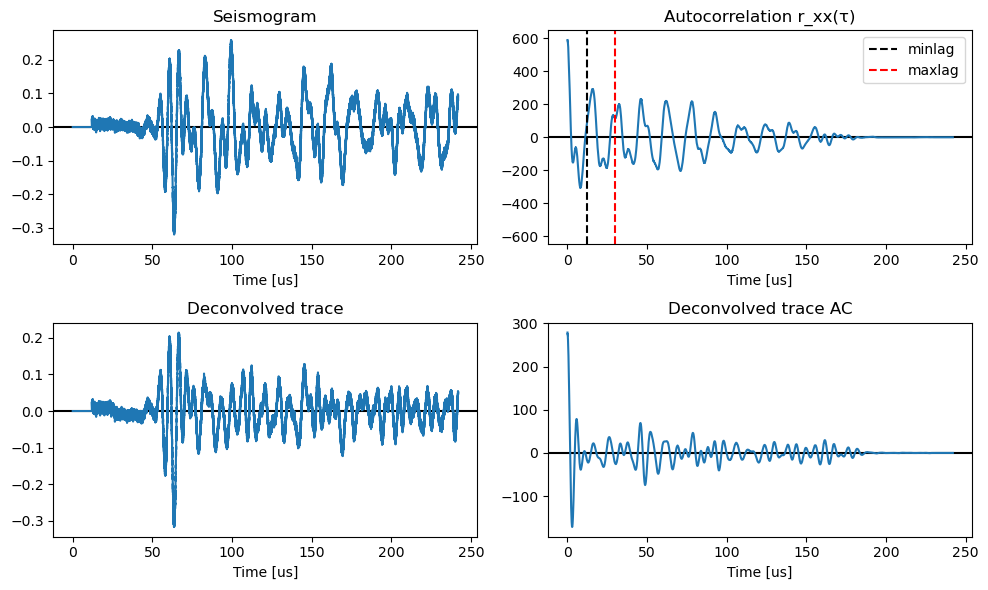

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

axs[0,0].axhline(0, color='k', ls='-',)
axs[0,0].plot(t, x)
axs[0,0].set_title("Seismogram")

axs[0,1].axhline(0, color='k', ls='-',)
axs[0,1].plot(t, r_full[mid:])
axs[0,1].axvline((minlag-1)*fs, color='k', ls='--', label='minlag')
axs[0,1].axvline(maxlag*fs, color='r', ls='--', label='maxlag')
axs[0,1].set_title("Autocorrelation r_xx(τ)")
axs[0,1].legend()
# axs[0,1].grid()
axs[0,1].set_ylim(-max(r_full[mid:])*1.1, max(r_full[mid:])*1.1)

axs[1,0].axhline(0, color='k', ls='-',)
axs[1,0].plot(t, x_decon)
axs[1,0].set_title("Deconvolved trace")

axs[1,1].axhline(0, color='k', ls='-',)
# axs[1,1].plot(t, r_full[x_decon_mid:]-  x_decon_ac[x_decon_mid:])
axs[1,1].plot(t, x_decon_ac[x_decon_mid:])
axs[1,1].set_title("Deconvolved trace AC")
# axs[1,1].plot(pef_operator)

for ax in axs.flat:
    ax.set_xlabel("Time [us]")
plt.tight_layout()
# plt.show()
